# Modélisation de l'incertitude sur le débit d'eau au niveau d'exutoires et points d'intérêt.

## Modélisation de la dépendance des débits des tronçons d'eau

Pour cette étude préalable, je considère que le débit d'eau au niveau d'un exutoire/infrastructure sera la somme de l'ensemble des débits des tronçons se rejoignant à l'exutoire.

$$\varepsilon_k = \sum_i q_{k-1}^i $$

où :
- $\varepsilon_k$ est le débit au niveau de l'exutoire étudié.
- $q_{k-1}^i$ est le débit du tronçon d'eau juste en amont de l'exutoire.

Le débit d'un tronçon à son aval est la somme de son débit en amont + un terme représentant une modification de ce dernier le long du trajet.

$$q_k = \varepsilon_{k-1} + \eta_k$$

- $\varepsilon_{k-1}$ est le débit au niveau de l'exutoire en amont du tronçon d'eau.
- $\eta_k$ est le terme additif représentant l'augmentation du débit venant due à la pluie, de retenues d'eau, drainages, ou autres phénomènes pouvant influencer le niveau d'eau le long du tronçon d'eau.

Ainsi le bassin versant d'un cours d'eau se reconstitue naturellement comme une succession de jonctions de tronçons d'eau.

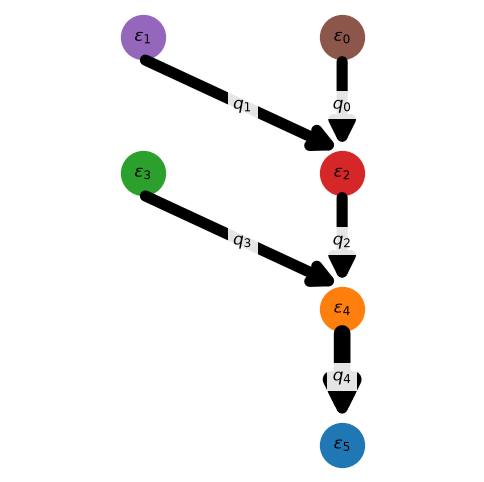

In [1]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 6))

# Positions des noeuds
pos = {
    r"$\varepsilon_5$": (0, -0.5),
    r"$\varepsilon_4$": (0, 0),
    r"$\varepsilon_3$": (-0.3, 0.5),
    r"$\varepsilon_2$": (0, 0.5),
    r"$\varepsilon_1$": (-0.3, 1.0),
    r"$\varepsilon_0$": (0, 1.0)
}

# Arêtes avec noms
edges = [
    (r"$\varepsilon_0$", r"$\varepsilon_2$", r"$q_0$"),
    (r"$\varepsilon_1$", r"$\varepsilon_2$", r"$q_1$"),
    (r"$\varepsilon_2$", r"$\varepsilon_4$", r"$q_2$"),
    (r"$\varepsilon_3$", r"$\varepsilon_4$", r"$q_3$"),
    (r"$\varepsilon_4$", r"$\varepsilon_5$", r"$q_4$"),
    ]

# Dessin des noeuds
for node, (x, y) in pos.items():
    ax.scatter(x, y, s=1000)
    ax.text(x, y, node, ha='center', va='center',
            fontsize=12, fontweight='bold')

# Dessin des flèches et labels
for start, end, label in edges:

    x_start, y_start = pos[start]
    x_end, y_end = pos[end]

    y_start -= 0.08
    y_end += 0.08

    ax.annotate(
        "",
        xy=(x_end, y_end),
        xytext=(x_start, y_start),
        arrowprops=dict(
            arrowstyle="->",
            lw=8,              # épaisseur de la flèche
            mutation_scale=30  # taille de la pointe
        )
    )

    # Position du texte au milieu de la flèche
    x_mid = (x_start + x_end) / 2
    y_mid = (y_start + y_end) / 2

    ax.text(
        x_mid,
        y_mid,
        label,
        fontsize=12,
        ha='center',
        va='center',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.9)
    )

from matplotlib.patches import FancyArrowPatch

arrow = FancyArrowPatch(
    (x_start, y_start),
    (x_end, y_end),
    arrowstyle='-|>',
    mutation_scale=40,
    linewidth=12
)
ax.add_patch(arrow)

ax.set_xlim(-0.5, 0.2)
ax.set_ylim(-0.6, 1.1)
ax.axis("off")

plt.show()

### Mise en données aligné avec les standards SIG

In [2]:
import pandas as pd
import geopandas as gpd

# Création de la dataframe contenant les propriétés des tonçons de cours d'eau
# Ajout d'une propriété NAME pour rendre l'exemple plus clair.
gdf = pd.DataFrame(columns=["HYRIV_ID",
                            "NAME",
                            "NEXT_DOWN",
                            "MAIN_RIV",
                            "LENGTH_KM",
                            "CATCH_SKM",
                            "DIS_AV_CMS",
                            "ENDORHEIC",
                            "ORD_STRA",
                            "geometry"],
                    index=[0, 1, 2, 3, 4])

gdf

,HYRIV_ID,NAME,NEXT_DOWN,MAIN_RIV,LENGTH_KM,CATCH_SKM,DIS_AV_CMS,ENDORHEIC,ORD_STRA,geometry
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Ajout des propriétés des tronçons

In [3]:
from numpy import random
for idx in gdf.index:
    # ID du tronçon
    gdf.loc[idx, "HYRIV_ID"] = idx

    gdf.loc[idx, "MAIN_RIV"] = 4

    # Longueur du tronçon (en km) : valeur aléatoire entre 1 et 10
    rand_length = random.uniform(1, 10)
    gdf.loc[idx, "LENGTH_KM"] = rand_length

    # Superficie du bassin versant local (en km²) : valeur aléatoire entre 5 et 10 fois la longueur du tronçon
    gdf.loc[idx, "CATCH_SKM"] = rand_length * random.uniform(5, 10)

    gdf.loc[idx, "ENDORHEIC"] = False

# Noms des tronçons (NAME)
gdf.loc[0, "NAME"] = "Orne_amont"
gdf.loc[1, "NAME"] = "Laize"
gdf.loc[2, "NAME"] = "Orne_millieu"
gdf.loc[3, "NAME"] = "Odon"
gdf.loc[4, "NAME"] = "Orne_aval"

# Tronçon suivant (NEXT_DOWN)
gdf.loc[0, "NEXT_DOWN"] = 2
gdf.loc[1, "NEXT_DOWN"] = 2
gdf.loc[2, "NEXT_DOWN"] = 4
gdf.loc[3, "NEXT_DOWN"] = 4
# Convention pour le tronçon terminal
gdf.loc[4, "NEXT_DOWN"] = 0

# Ordre de Strahler (ORD_STRA)
gdf.loc[0, "ORD_STRA"] = 1
gdf.loc[1, "ORD_STRA"] = 1
gdf.loc[2, "ORD_STRA"] = 2
gdf.loc[3, "ORD_STRA"] = 1
gdf.loc[4, "ORD_STRA"] = 3


gdf


,HYRIV_ID,NAME,NEXT_DOWN,MAIN_RIV,LENGTH_KM,CATCH_SKM,DIS_AV_CMS,ENDORHEIC,ORD_STRA,geometry
0,0,Orne_amont,2,4,9.469011,59.471556,NaN,False,1,NaN
1,1,Laize,2,4,8.152765,50.691661,NaN,False,1,NaN
2,2,Orne_millieu,4,4,2.324831,18.266057,NaN,False,2,NaN
3,3,Odon,4,4,6.836851,43.009033,NaN,False,1,NaN
4,4,Orne_aval,0,4,8.312049,56.447981,NaN,False,3,NaN


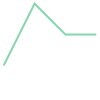

In [4]:
# On ne met pas les géometries dans la dataframe initiale,
# mais on peut les ajouter ensuite pour créer un GeoDataFrame.
from shapely.geometry import LineString

trajet = LineString([
    (1.0, 20.3),
    (1.1, 20.5),
    (1.2, 20.4),
    (1.3, 20.4)
])

trajet

Le paramètre `DIS_AV_CMS`représente le débit moyen en aval de la section.

Si on considère une valeur fixe pour les exutoires $\varepsilon_1$, $\varepsilon_2$ et $\varepsilon_4$, respectivement, les tronçons $q_1$, $q_2$ et $q_4$ verront leurs débits dépendre du débit au niveau de ces termes sources.

NB: il est aussi possible de considérer ces termes comme nuls, ainsi le débit en aval de ces tronçons ne dépendra uniquement que du gain d'eau au long de ce tronçon.

In [11]:
import numpy as np

# La valeur du débit au niveau d'un exutoire:
# - 0 si l'exutoire en au moins en aval d'un tronçon d'enumerate
# - non null si il est un terme source en amont du réseau (il peut aussi être null en amont)
list_epsilon = [1, 1, 0, 1, 0, 0] 
list_q = [np.nan for _ in range(gdf.shape[0])]

# Pour ce cas simple, on supposera que le terme additif eta dependra de la surface du bassin versant local 
# Par exemple, si il pleut, cette surface peut être utilisée pour estimer la quantité d'eau qui s'écoule dans le tronçon.

# L'idée est de calculer les débits des tronçons d'ordre 1, puis d'ordre 2, puis d'ordre 3, etc...
max_order = max(gdf["ORD_STRA"])
for i_stra in range(1, max_order + 1):

    # On récupère les tronçons d'ordre i_stra
    idx_stra = gdf[gdf["ORD_STRA"] == i_stra].index

    print(f"Calcul des débits pour les tronçons d'ordre {i_stra}:")
    print(idx_stra, "\n")

    for idx in idx_stra:
        # Dabord, on ajoute le terme de l'exutoire en amont, si il existe
        q = list_epsilon[idx]

        # Puis on rajoute un terme additif eta, qui dépend de la surface du bassin versant local
        def eta_func(catch_skm):
            return catch_skm * 0.1
        eta = eta_func(gdf.loc[idx, "CATCH_SKM"])

        q += eta

        # Debit du tronçon
        list_q[idx] = q

        # Il faut maintenant mettre à jour le debit de l'exutoire en aval de ces tronçons
        # On identifie d'abord l'exutoire en aval du tronçon
        next_down_idx = gdf.loc[idx, "NEXT_DOWN"]
        # Puis on ajoute le debit du tronçon au debit de l'exutoire en aval
        # Cas spécial pour le tronçon terminal, qui n'a pas d'exutoire en aval
        if next_down_idx == 0:
            list_epsilon[-1] += q
        else:
            list_epsilon[next_down_idx] += q

Calcul des débits pour les tronçons d'ordre 1:
Index([0, 1, 3], dtype='int64') 

Calcul des débits pour les tronçons d'ordre 2:
Index([2], dtype='int64') 

Calcul des débits pour les tronçons d'ordre 3:
Index([4], dtype='int64') 



In [12]:
list_q

[6.947155634874681,
 6.06916611456266,
 14.842927411506174,
 5.300903280773124,
 25.788628841665187]

In [13]:
list_epsilon

[1, 1, 13.016321749437342, 1, 20.1438306922793, 25.788628841665187]

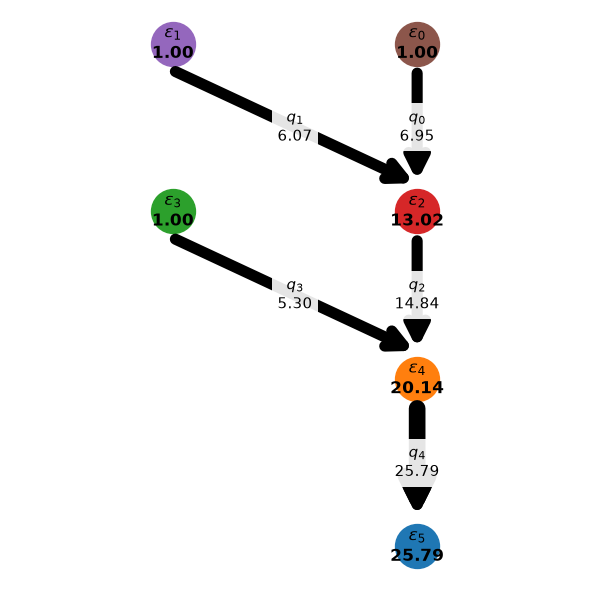

In [14]:
fig, ax = plt.subplots(figsize=(6, 6))

# Positions des noeuds
pos = {
    5: (0, -0.5),
    4: (0, 0),
    3: (-0.3, 0.5),
    2: (0, 0.5),
    1: (-0.3, 1.0),
    0: (0, 1.0)
}

# Arêtes : (départ, arrivée, indice q)
edges = [
    (0, 2, 0),
    (1, 2, 1),
    (2, 4, 2),
    (3, 4, 3),
    (4, 5, 4),
]

# Dessin des noeuds
for idx, (x, y) in pos.items():

    ax.scatter(x, y, s=1000)

    ax.text(
        x,
        y,
        rf"$\varepsilon_{{{idx}}}$" + f"\n{list_epsilon[idx]:.2f}",
        ha="center",
        va="center",
        fontsize=12,
        fontweight="bold",
    )

# Dessin des flèches et labels
for start, end, q_idx in edges:

    x_start, y_start = pos[start]
    x_end, y_end = pos[end]

    y_start -= 0.08
    y_end += 0.08

    ax.annotate(
        "",
        xy=(x_end, y_end),
        xytext=(x_start, y_start),
        arrowprops=dict(
            arrowstyle="->",
            lw=8,
            mutation_scale=30
        )
    )

    x_mid = (x_start + x_end) / 2
    y_mid = (y_start + y_end) / 2

    ax.text(
        x_mid,
        y_mid,
        rf"$q_{{{q_idx}}}$" + f"\n{list_q[q_idx]:.2f}",
        fontsize=11,
        ha="center",
        va="center",
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.9
        )
    )

# Flèche épaisse finale (optionnelle)
x_start, y_start = pos[4]
x_end, y_end = pos[5]

y_start -= 0.08
y_end += 0.08

arrow = FancyArrowPatch(
    (x_start, y_start),
    (x_end, y_end),
    arrowstyle='-|>',
    mutation_scale=40,
    linewidth=12
)
ax.add_patch(arrow)

ax.set_xlim(-0.5, 0.2)
ax.set_ylim(-0.6, 1.1)
ax.axis("off")

plt.tight_layout()
plt.show()

## Prise en compte de l'incertitude

Il faut maintenant un moyen de modéliser l'incertitude sur chacun de ces éléments.
Si possible une distribution de probabilité vraisemblable et capable de modéliser la propagation d'incertitude d'un bassin versant vers un exutoire.

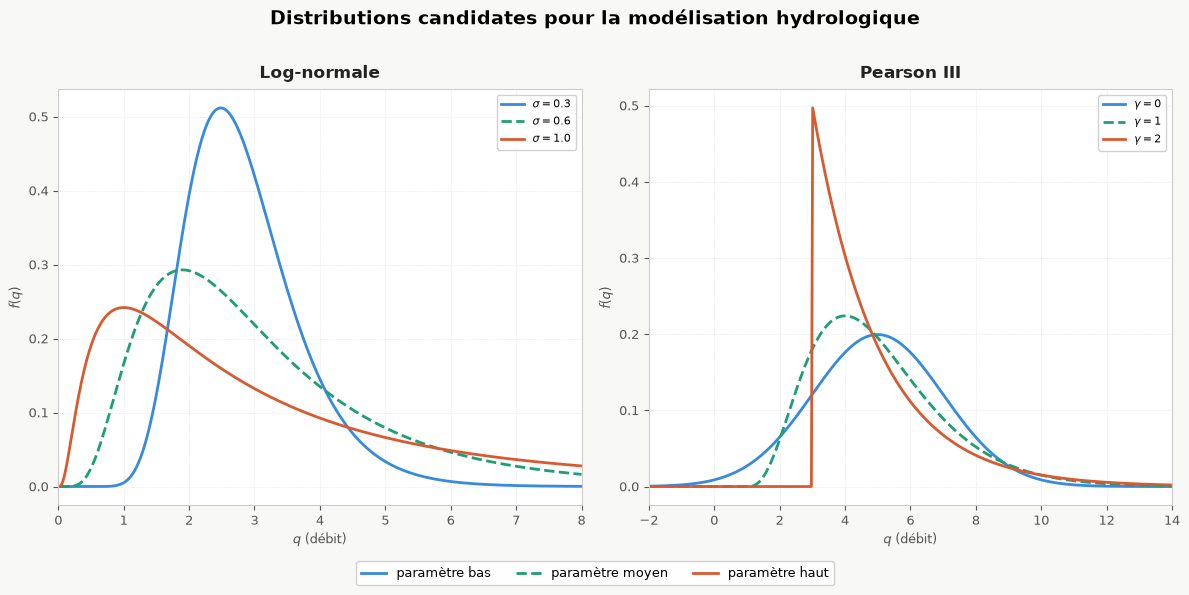

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from scipy import stats

# ── Palette ──────────────────────────────────────────────────────────────────
COLORS = ["#378ADD", "#1D9E75", "#D85A30"]
DASHES = ["-", "--", "-"]

# ── Helpers ───────────────────────────────────────────────────────────────────
def pearson3_pdf(x, mu, sigma, gamma):
    """Pearson III (Gamma décalée):
    - mu: moyenne
    - sigma: écart-type
    - gamma: coefficient d'asymétrie (skewness)"""
    if abs(gamma) < 1e-6:
        return stats.norm.pdf(x, loc=mu, scale=sigma)
    # Definition des paramètres de la distribution Gamma
    alpha = 4 / gamma**2
    beta  = sigma * abs(gamma) / 2
    # Calcul de la valeur centrale de la distribution Gamma décalée
    xi    = mu - 2 * sigma / gamma
    # Calcul de la variable transformée
    y     = (x - xi) if gamma > 0 else (xi - x)
    # mask pour éviter les valeurs négatives dans la distribution Gamma
    mask  = y > 0
    out   = np.zeros_like(x, dtype=float)
    out[mask] = stats.gamma.pdf(y[mask], a=alpha, scale=beta)
    return out

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle("Distributions candidates pour la modélisation hydrologique",
             fontsize=14, fontweight="bold", y=0.98)
fig.patch.set_facecolor("#F8F8F6")

PANEL_STYLE = dict(facecolor="white", edgecolor="#CCCCCC", linewidth=0.8)
for ax in axes.flat:
    ax.set_facecolor("white")
    for spine in ax.spines.values():
        spine.set_edgecolor("#CCCCCC")
        spine.set_linewidth(0.8)
    ax.tick_params(colors="#555555", labelsize=9)
    ax.grid(True, linestyle=":", linewidth=0.5, color="#DDDDDD", zorder=0)

# ── Log-normale ────────────────────────────────────────────────────────────
ax = axes[0]
x = np.linspace(0.01, 8, 400)
params = [(1, 0.3), (1, 0.6), (1, 1.0)]
labels = [r"$\sigma=0.3$", r"$\sigma=0.6$", r"$\sigma=1.0$"]
for (mu, sigma), label, color, dash in zip(params, labels, COLORS, DASHES):
    ax.plot(x, stats.lognorm.pdf(x, s=sigma, scale=np.exp(mu)),
            color=color, linestyle=dash, linewidth=2, label=label)
ax.set_title("Log-normale", fontsize=12, fontweight="bold", pad=8, color="#222")
ax.set_xlabel(r"$q$ (débit)", fontsize=9, color="#555")
ax.set_ylabel(r"$f(q)$", fontsize=9, color="#555")
ax.legend(fontsize=8, framealpha=0.9, edgecolor="#CCCCCC")
ax.set_xlim(0, 8)

# ── Pearson III ────────────────────────────────────────────────────────────
ax = axes[1]
x = np.linspace(-2, 14, 400)
params = [(5, 2, 0), (5, 2, 1), (5, 2, 2)]
labels = [r"$\gamma=0$", r"$\gamma=1$", r"$\gamma=2$"]
for (mu, sigma, gamma), label, color, dash in zip(params, labels, COLORS, DASHES):
    ax.plot(x, pearson3_pdf(x, mu, sigma, gamma),
            color=color, linestyle=dash, linewidth=2, label=label)
ax.set_title("Pearson III", fontsize=12, fontweight="bold", pad=8, color="#222")
ax.set_xlabel(r"$q$ (débit)", fontsize=9, color="#555")
ax.set_ylabel(r"$f(q)$", fontsize=9, color="#555")
ax.legend(fontsize=8, framealpha=0.9, edgecolor="#CCCCCC")
ax.set_xlim(-2, 14)

# ── Légende commune ───────────────────────────────────────────────────────────
legend_handles = [
    mlines.Line2D([], [], color=COLORS[0], linestyle="-",  linewidth=2, label="paramètre bas"),
    mlines.Line2D([], [], color=COLORS[1], linestyle="--", linewidth=2, label="paramètre moyen"),
    mlines.Line2D([], [], color=COLORS[2], linestyle="-",  linewidth=2, label="paramètre haut"),
]
fig.legend(handles=legend_handles, loc="lower center", ncol=3,
           fontsize=9, framealpha=0.9, edgecolor="#CCCCCC",
           bbox_to_anchor=(0.5, 0.01))

plt.tight_layout(rect=[0, 0.06, 1, 0.97])

plt.show()

- Log-normal :  si les débits de plusieurs tronçons sont log-normaux et indépendants, leur somme ne l'est pas. En revanche, les produits le sont, mais cela ne nous intéresse pas.

- Distribution Gamma et Pearson III : deux distributions similaires à la différence d'un     décallage. Définit sur $[x_0, +\infty[$, elles ont une propriété de reproductibilité, c'est-à-dire que si $q_1 \sim \Gamma (\alpha_1, \beta)$ et $q_2 \sim \Gamma (\alpha_2, \beta)$, alors $q_1 + q_2 \sim \Gamma (\alpha_1 + \alpha_2, \beta)$

Ainsi la distribution **Pearson III** semble la candidate idéale. Il est cependant à noter que pour exploiter la propriété de reproductibilité, cette dernière repose sur la fonction génératrice des moments, tel que :
$$
X \sim \Gamma(\alpha, \beta) 
~~~\text{avec}~~~ 
M_X​(t) = (1−\beta t)^{−\alpha} 
$$

Donc dans le cas $Q_3 = Q_1 + Q_2$ indépendants, on a :
$$
\begin{align*}
M_{Q_3}(t)
    &= M_{Q_1}(t) \cdot M_{Q_2}(t) \\
    &= (1−\beta_1 t)^{−\alpha_1} (1−\beta_2 t)^{−\alpha_2} \\
    \text{si} ~~ \beta_1 = \beta_2 \\
    &= (1−\beta t)^{−(\alpha_1 + \alpha_2)}
\end{align*}
$$

Où on a :
$$
\beta  = \frac{\sigma ~ |\gamma|}{ 2 } ~~~\text{si}~~~ \gamma \neq 0
$$
Avec :
- $\sigma$ : l'écart-type
- $\gamma$ : le coefficient d'asymétrie

$\beta$ est l'échelle de la distribution : il encode la "taille typique" des événements. Exiger $\beta$ identique revient à dire que tous les tronçons ont la même variabilité relative par rapport à leur débit moyen, ce qui est une hypothèse forte.

Ainsi cela pourrait être adapté pour des tronçons homogènes en termes de variabilité (même régime pluviométrique). Mais les grands modèles hydrologiques couvrent des tronçons hétérogènes.

### Solutions

Si on travaille avec des sous-bassins relativement homogènes (même climatologie, coefficients de ruissellement proches), on peut estimer un $\beta$ commun par maximum de vraisemblance.
Si ce n'est pas possible, il faut utiliser la méthode de Monte-Carlo en tirant des réalisations de chaque tronçon. Si on en arrive à ce cas de figure, la distribution gamma peut être remplacée par une distribution plus flexible et physiquement plausible.